In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Loading the dataset from  provided GitHub link
url = "https://raw.githubusercontent.com/salemprakash/EDA/main/Data/HepatitisCdata.csv"
df = pd.read_csv(url )

# Display basic info
print("Dataset Loaded Successfully!")
display(df.head())
df.info()


Dataset Loaded Successfully!


,Unnamed: 0,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,1,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,2,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,3,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,4,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,5,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 615 entries, 0 to 614
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  615 non-null    int64  
 1   Category    615 non-null    object 
 2   Age         615 non-null    int64  
 3   Sex         615 non-null    object 
 4   ALB         614 non-null    float64
 5   ALP         597 non-null    float64
 6   ALT         614 non-null    float64
 7   AST         615 non-null    float64
 8   BIL         615 non-null    float64
 9   CHE         615 non-null    float64
 10  CHOL        605 non-null    float64
 11  CREA        615 non-null    float64
 12  GGT         615 non-null    float64
 13  PROT        614 non-null    float64
dtypes: float64(10), int64(2), object(2)
memory usage: 67.4+ KB


In [2]:
#bais stats analyisis

In [3]:
# Drop the unnecessary index column if it exists
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print("--- Numerical Summary Statistics ---")
display(df.describe())

print("\n--- Categorical Summary Statistics ---")
display(df.describe(include=['O']))

print("\n--- Target Variable (Category) Distribution ---")
print(df['Category'].value_counts())


--- Numerical Summary Statistics ---


,Age,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
count,615.000000,614.000000,597.000000,614.000000,615.000000,615.000000,615.000000,605.000000,615.000000,615.000000,614.000000
mean,47.408130,41.620195,68.283920,28.450814,34.786341,11.396748,8.196634,5.368099,81.287805,39.533171,72.044137
std,10.055105,5.780629,26.028315,25.469689,33.090690,19.673150,2.205657,1.132728,49.756166,54.661071,5.402636
min,19.000000,14.900000,11.300000,0.900000,10.600000,0.800000,1.420000,1.430000,8.000000,4.500000,44.800000
25%,39.000000,38.800000,52.500000,16.400000,21.600000,5.300000,6.935000,4.610000,67.000000,15.700000,69.300000
50%,47.000000,41.950000,66.200000,23.000000,25.900000,7.300000,8.260000,5.300000,77.000000,23.300000,72.200000
75%,54.000000,45.200000,80.100000,33.075000,32.900000,11.200000,9.590000,6.060000,88.000000,40.200000,75.400000
max,77.000000,82.200000,416.600000,325.300000,324.000000,254.000000,16.410000,9.670000,1079.100000,650.900000,90.000000



--- Categorical Summary Statistics ---


,Category,Sex
count,615,615
unique,5,2
top,0=Blood Donor,m
freq,533,377



--- Target Variable (Category) Distribution ---
Category
0=Blood Donor             533
3=Cirrhosis                30
1=Hepatitis                24
2=Fibrosis                 21
0s=suspect Blood Donor      7
Name: count, dtype: int64


In [4]:
#Handling missing data

In [5]:
print("--- Missing Values Before Handling ---")
print(df.isnull().sum())


for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df.groupby('Category')[col].transform('median'))

# Final check to ensure no missing values remain
print("\n-----Missing Values After Imputation ------")
print(df.isnull().sum().sum())


--- Missing Values Before Handling ---
Category     0
Age          0
Sex          0
ALB          1
ALP         18
ALT          1
AST          0
BIL          0
CHE          0
CHOL        10
CREA         0
GGT          0
PROT         1
dtype: int64

--- Missing Values After Imputation ---
0


In [6]:
#Data cleaning

In [7]:
# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()

# Clean string values (removing any extra whitespace)
df['Sex'] = df['Sex'].str.strip()
df['Category'] = df['Category'].str.strip()

print("Data Cleaning Completed.")


Number of duplicate rows: 0
Data Cleaning Completed.


In [8]:
#Data Transformation

In [9]:
from sklearn.preprocessing import LabelEncoder

# 1. Feature Engineering: Create AST/ALT ratio
df['AST_ALT_Ratio'] = df['AST'] / df['ALT']

# 2. Encoding Categorical Variables
le = LabelEncoder()
df['Sex_Encoded'] = le.fit_transform(df['Sex'])

# Encode Category to numeric values for analysis
df['Category_Encoded'] = le.fit_transform(df['Category'])

print("Data Transformation Completed. New columns added: AST_ALT_Ratio, Sex_Encoded, Category_Encoded.")
display(df.head())


Data Transformation Completed. New columns added: AST_ALT_Ratio, Sex_Encoded, Category_Encoded.


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT,AST_ALT_Ratio,Sex_Encoded,Category_Encoded
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0,2.870130,1,0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5,1.372222,1,0
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3,1.453039,1,0
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7,0.738562,1,0
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7,0.760736,1,0


In [10]:
#Univariate Analysis

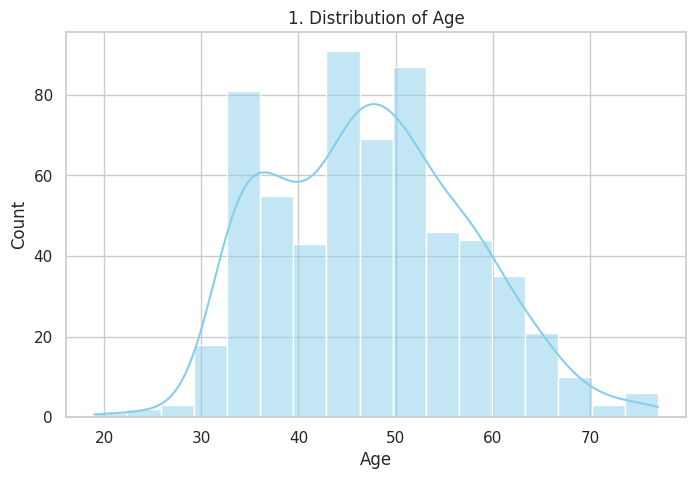

In [11]:
# 1. Age Distribution (Histogram)
plt.figure(figsize=(8, 5))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('1. Distribution of Age')
plt.show()




/tmp/ipykernel_661/3815026095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Category', palette='viridis')


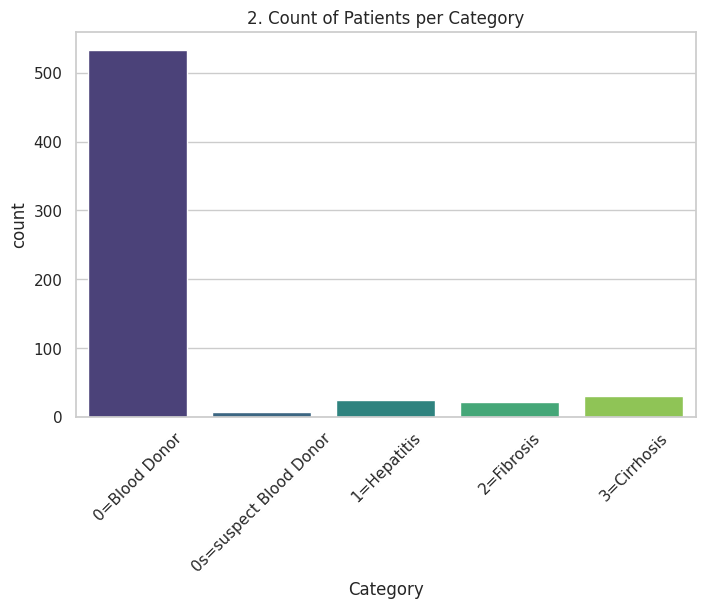

In [12]:
# 2. Category Counts (Bar Chart)
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Category', palette='viridis')
plt.title('2. Count of Patients per Category')
plt.xticks(rotation=45)
plt.show()



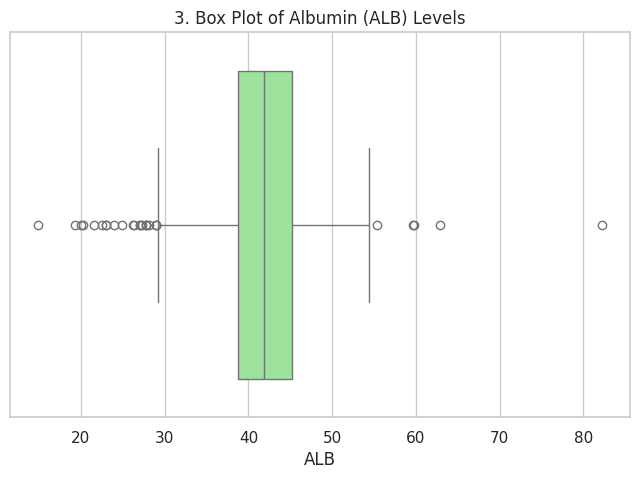

In [13]:
# 3. Albumin (ALB) Spread (Box Plot)
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['ALB'], color='lightgreen')
plt.title('3. Box Plot of Albumin (ALB) Levels')
plt.show()

In [14]:
#Bivariate Analysis

/tmp/ipykernel_661/4183001895.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Category', y='Age', palette='Set2')


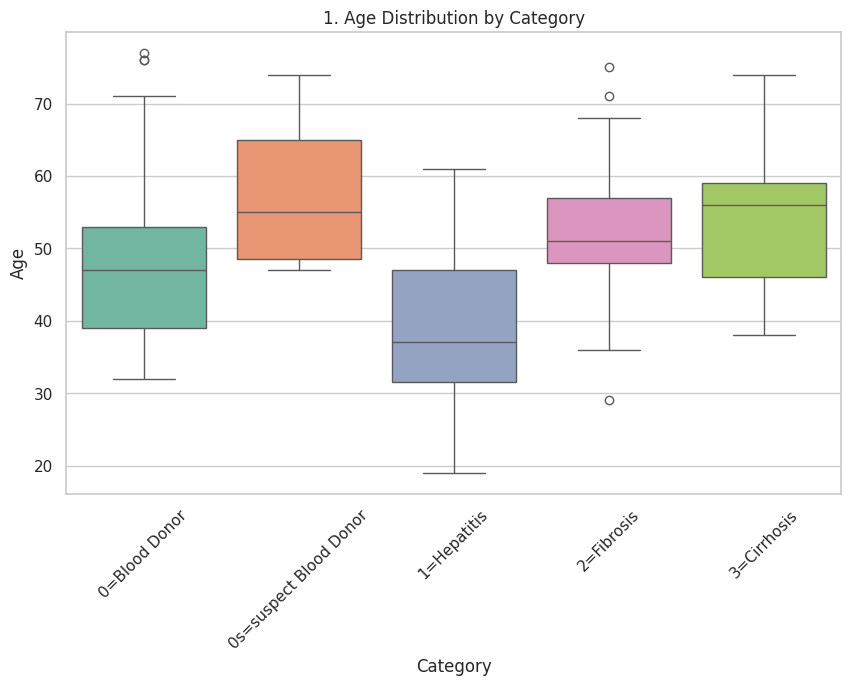

In [15]:
# 1. Age vs Category (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Age', palette='Set2')
plt.title('1. Age Distribution by Category')
plt.xticks(rotation=45)
plt.show()




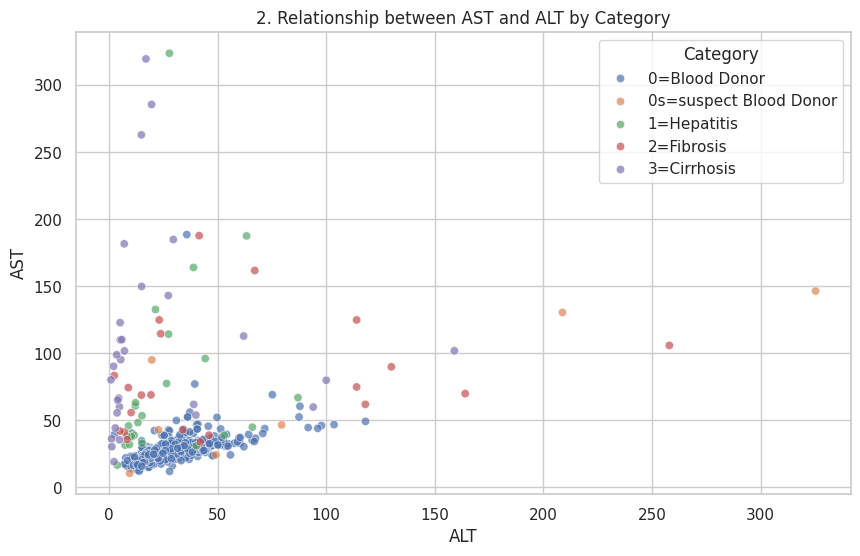

In [16]:
# 2. AST vs ALT (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='ALT', y='AST', hue='Category', alpha=0.7)
plt.title('2. Relationship between AST and ALT by Category')
plt.show()



/tmp/ipykernel_661/814476455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Category', y='BIL', palette='magma')


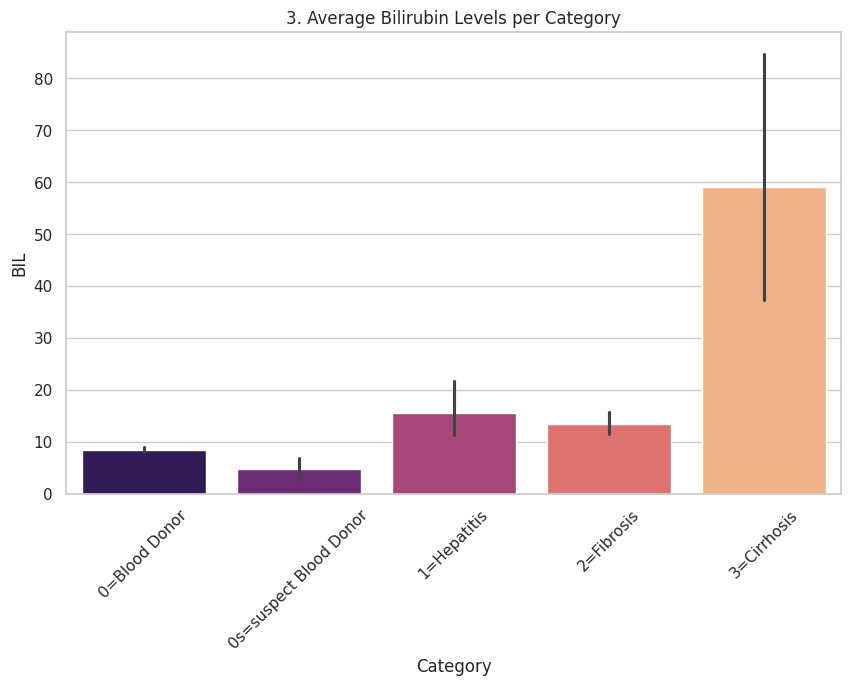

In [17]:
# 3. Mean Bilirubin (BIL) by Category (Bar Plot)
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='BIL', palette='magma')
plt.title('3. Average Bilirubin Levels per Category')
plt.xticks(rotation=45)
plt.show()

In [18]:
#Multivariate Analysis

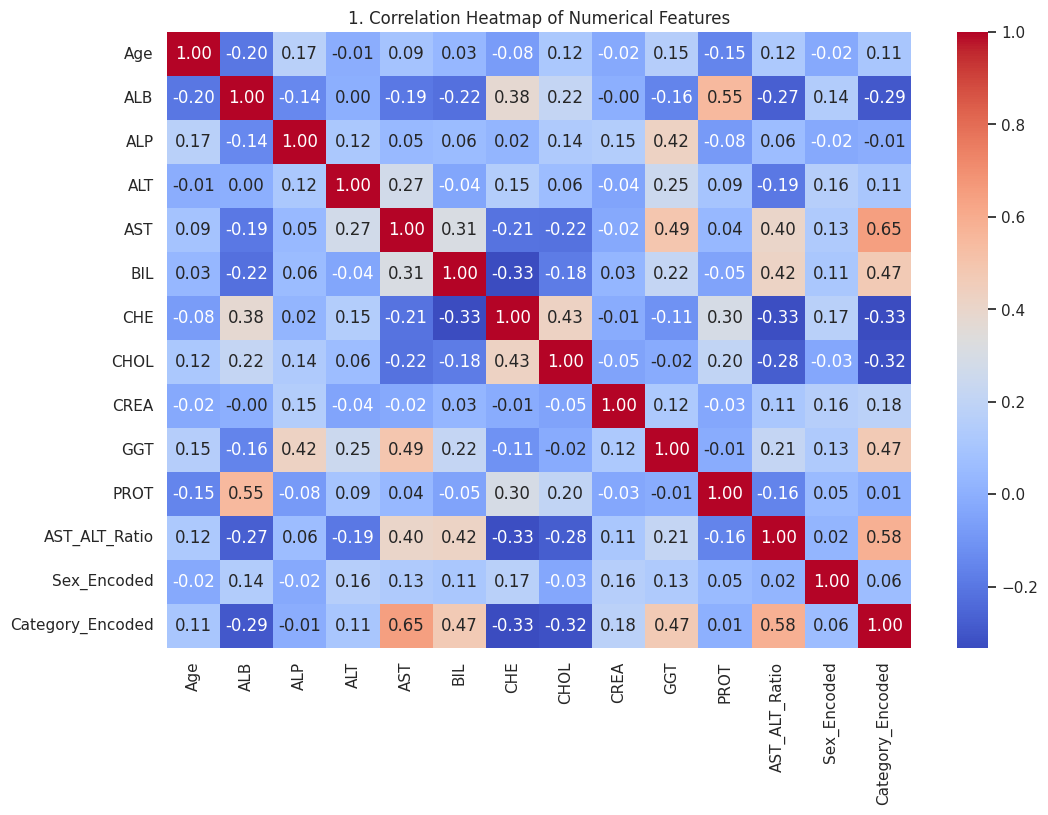

In [19]:
# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('1. Correlation Heatmap of Numerical Features')
plt.show()




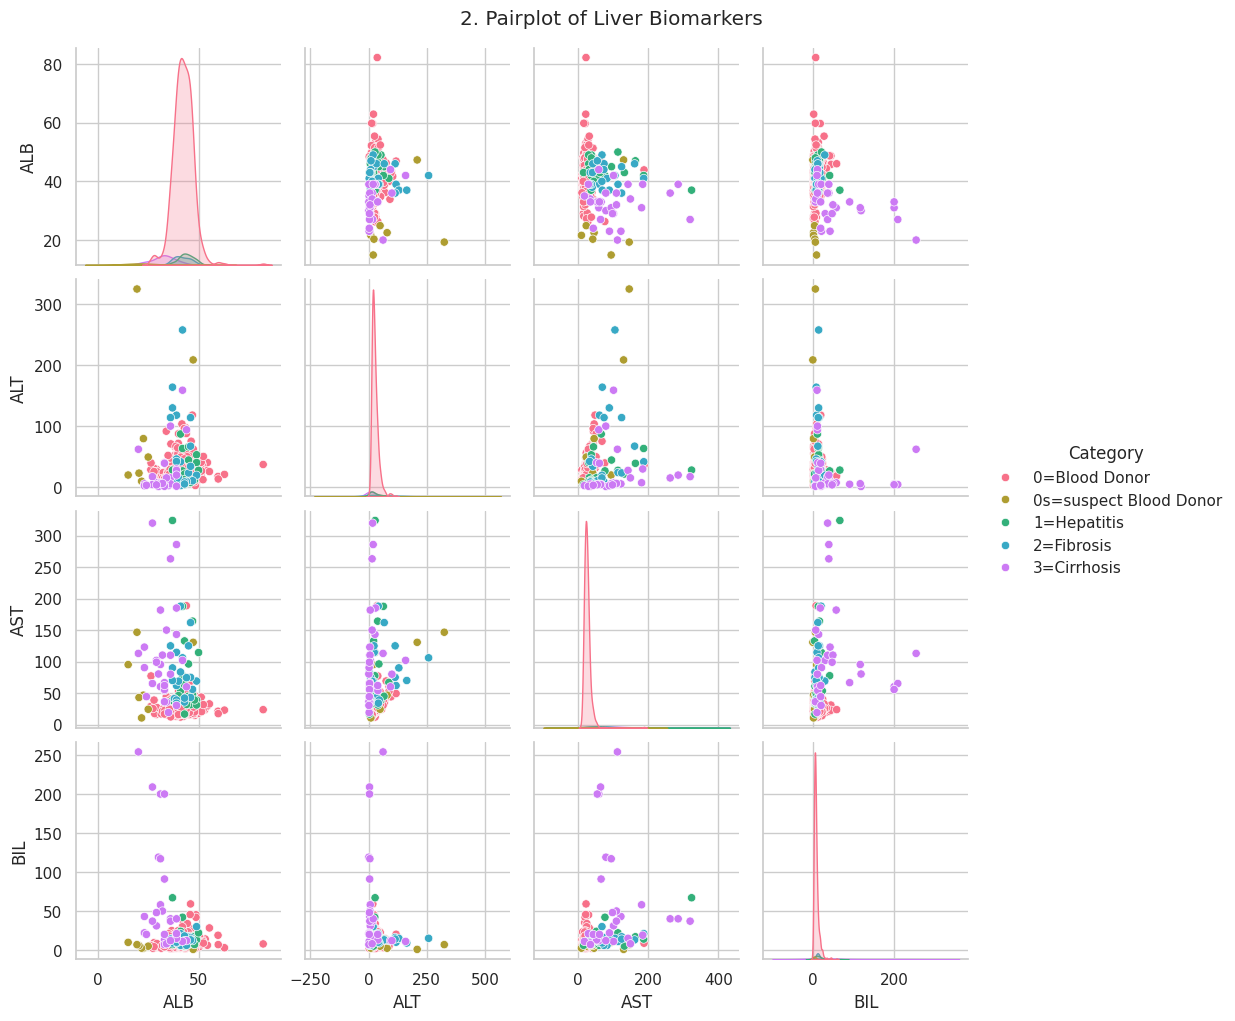

In [20]:
# 2. Pairplot of Key Biomarkers
sns.pairplot(df[['ALB', 'ALT', 'AST', 'BIL', 'Category']], hue='Category', palette='husl')
plt.suptitle('2. Pairplot of Liver Biomarkers', y=1.02)
plt.show()



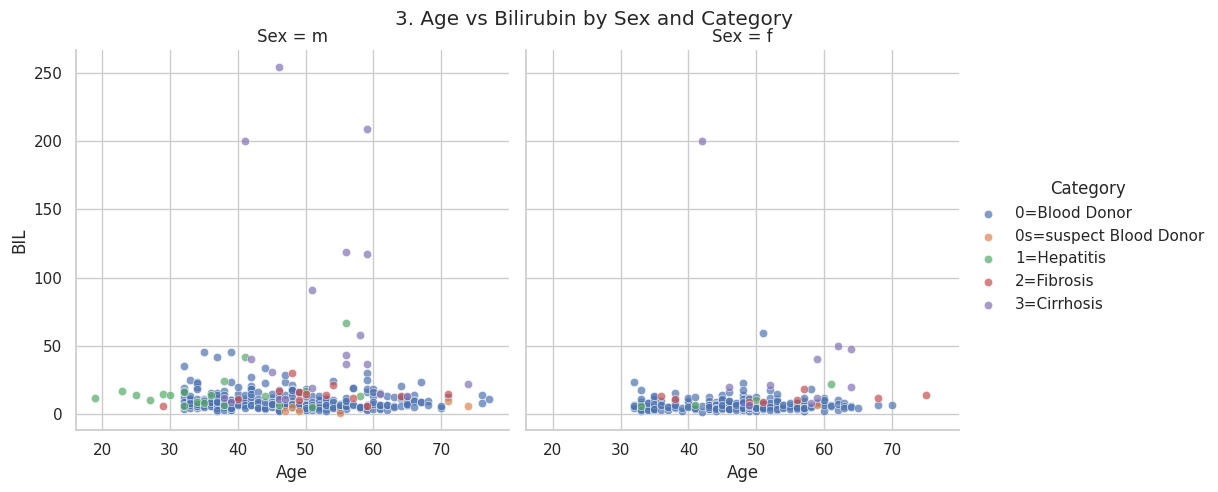

In [21]:
# 3. Age vs. Bilirubin by Sex and Category (Facet Grid)
g = sns.FacetGrid(df, col="Sex", hue="Category", height=5)
g.map(sns.scatterplot, "Age", "BIL", alpha=.7)
g.add_legend()
plt.subplots_adjust(top=0.9)
g.fig.suptitle('3. Age vs Bilirubin by Sex and Category')
plt.show()